# Fast Vortexmap from Pre-computed Bootstrap Values

This notebook contains a vortexmap implementation that works directly with pre-computed bootstrap arrays,
avoiding the need to run DABEST computation each time. This is much faster for large datasets (200+ genotypes).

The core functions are copied exactly from the original DABEST implementation in `dabest/multi.py` to ensure
identical visual output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import List, Optional, Union, Tuple, Dict, Any

In [2]:
def _sample_bootstrap(bootstrap, m, n, reverse_neg, abs_rank, chop_tail):
    """Sample bootstrap values and prepare for spiral visualization.
    
    This function is copied exactly from dabest/multi.py lines 547-564
    to ensure identical behavior.
    """
    bootstrap_sorted = sorted(bootstrap)
    chop_tail_int = int(np.ceil(len(bootstrap_sorted) * chop_tail / 100))
    bootstrap_sorted = bootstrap_sorted[chop_tail_int : len(bootstrap_sorted) - chop_tail_int]
    
    ranks_to_look = np.linspace(0, len(bootstrap_sorted), m * n, dtype=int)   
    ranks_to_look[0] = 1
    
    if np.sum(np.array(bootstrap_sorted) > 0) < len(bootstrap_sorted) / 2:
        if reverse_neg:
            bootstrap_sorted = bootstrap_sorted[::-1]
    
    if abs_rank:
        bootstrap_sorted = sorted(bootstrap_sorted, key=abs)
    
    long_ranks = [bootstrap_sorted[r - 1] for r in ranks_to_look]
    return long_ranks

def _spiralize(fill, m, n):
    """Convert linear array into spiral pattern.
    
    This function is copied exactly from dabest/multi.py lines 567-610
    to ensure identical behavior.
    """
    i = 0
    j = 0
    k = 0
    array = np.zeros((m, n))
    
    while m > 0 and k < len(fill):
        jj = j
        ii = i
        
        # Right
        for j in range(j, n):
            if k >= len(fill):
                break
            array[i, j] = fill[k]
            k += 1
        
        # Down
        for i in range(ii + 1, m):
            if k >= len(fill):
                break
            array[i, j] = fill[k]
            k += 1
        
        # Left
        for j in range(n - 2, jj - 1, -1):
            if k >= len(fill):
                break
            array[i, j] = fill[k]
            k += 1
        
        # Up
        for i in range(m - 2, ii, -1):
            if k >= len(fill):
                break
            array[i, j] = fill[k]
            k += 1
        
        m -= 1
        n -= 1
        j += 1
        
    return array

def fast_vortexmap(bootstrap_data, 
                   labels=None, 
                   row_labels=None,
                   n=21, 
                   sort_by=None, 
                   cmap='vlag', 
                   vmax=None, 
                   vmin=None, 
                   reverse_neg=True, 
                   abs_rank=False, 
                   chop_tail=0, 
                   ax=None,
                   fig_size=None, 
                   heatmap_kwargs=None):
    """
    Create a vortexmap visualization from pre-computed bootstrap values.
    
    This function replicates the exact behavior of the original vortexmap() function
    from dabest/multi.py but works directly with bootstrap arrays instead of 
    MultiContrast objects.
    
    Parameters
    ----------
    bootstrap_data : Union[List[List[float]], List[List[List[float]]]]
        Bootstrap values. Can be:
        - 1D: [bootstrap_array1, bootstrap_array2, ...] for horizontal layout
        - 2D: [[bootstrap_array1, bootstrap_array2], [bootstrap_array3, bootstrap_array4]] for grid layout
        Each bootstrap array should contain 5000 values for optimal performance.
    labels : List[str], optional
        Column labels for the contrasts
    row_labels : List[str], optional  
        Row labels (only used for 2D layouts)
    n : int, default 21
        Size of each spiral (n x n grid per contrast)
    sort_by : List[int], optional
        Order to sort contrasts by (indices)
    cmap : str, default 'vlag'
        Colormap for visualization
    vmax, vmin : float, optional
        Color scale limits
    reverse_neg : bool, default True
        Whether to reverse negative bootstrap values
    abs_rank : bool, default False
        Whether to rank by absolute value
    chop_tail : float, default 0
        Percentage of extreme values to exclude from each bootstrap
    ax : matplotlib.Axes, optional
        Existing axes to plot on
    fig_size : tuple, optional
        Figure size (width, height) in inches
    heatmap_kwargs : dict, optional
        Additional arguments passed to sns.heatmap()
    
    Returns
    -------
    tuple
        (figure, axes, mean_delta_dataframe) if ax is None, 
        else (axes, mean_delta_dataframe)
        
    Examples
    --------
    # 1D layout (horizontal) with 5000 bootstrap values each
    bootstrap_1d = [np.random.normal(1, 0.5, 5000), 
                    np.random.normal(-0.5, 0.3, 5000),
                    np.random.normal(2, 0.8, 5000)]
    fig, ax, means = fast_vortexmap(bootstrap_1d, 
                                    labels=['Drug A', 'Drug B', 'Drug C'])
    
    # 2D layout (grid) with 5000 bootstrap values each
    bootstrap_2d = [[np.random.normal(1, 0.5, 5000), np.random.normal(-0.5, 0.3, 5000)],
                    [np.random.normal(2, 0.8, 5000), np.random.normal(0.1, 0.2, 5000)]]
    fig, ax, means = fast_vortexmap(bootstrap_2d,
                                    labels=['Treatment 1', 'Treatment 2'],
                                    row_labels=['Genotype A', 'Genotype B'])
    """
    
    if heatmap_kwargs is None:
        heatmap_kwargs = {}
    
    # Determine structure (1D vs 2D)
    if isinstance(bootstrap_data[0], (list, np.ndarray)) and \
       len(bootstrap_data[0]) > 0 and \
       isinstance(bootstrap_data[0][0], (list, np.ndarray)):
        # 2D structure
        was_1d = False
        n_rows = len(bootstrap_data)
        n_cols = len(bootstrap_data[0])
        
        # Validate rectangular structure
        for i, row in enumerate(bootstrap_data):
            if len(row) != n_cols:
                raise ValueError(f"All rows must have the same number of bootstrap arrays. Row {i} has {len(row)}, expected {n_cols}")
    else:
        # 1D structure - convert to 2D for uniform processing
        was_1d = True
        bootstrap_data = [bootstrap_data]  # Wrap in single row
        n_rows = 1
        n_cols = len(bootstrap_data[0])
    
    # Handle labels
    if labels is None:
        col_labels = [f"Contrast {i+1}" for i in range(n_cols)]
    else:
        if len(labels) != n_cols:
            raise ValueError(f"Number of labels ({len(labels)}) must match number of columns ({n_cols})")
        col_labels = labels
    
    if was_1d:
        row_labels = [""]
    else:
        if row_labels is None:
            row_labels = [f"Row {i+1}" for i in range(n_rows)]
        else:
            if len(row_labels) != n_rows:
                raise ValueError(f"Number of row_labels ({len(row_labels)}) must match number of rows ({n_rows})")
    
    # Initialize spirals and mean_delta DataFrames  
    # This logic is copied from dabest/multi.py lines 677-682
    spirals = pd.DataFrame(np.zeros((n_rows * n, n_cols * n)))
    mean_delta = pd.DataFrame(np.zeros((n_rows, n_cols)), 
                             columns=col_labels, 
                             index=row_labels)
    
    # Process each bootstrap array into spirals
    # This logic is adapted from dabest/multi.py lines 687-707
    for i in range(n_rows):
        for j in range(n_cols):
            contrast_idx = sort_by[j] if sort_by is not None else j
            
            # Get bootstrap array for this position
            bootstrap = bootstrap_data[i][contrast_idx]
            
            # Convert to numpy array if needed
            if not isinstance(bootstrap, np.ndarray):
                bootstrap = np.array(bootstrap)
            
            # Sample bootstrap values for spiral (exact copy of original logic)
            long_ranks = _sample_bootstrap(bootstrap, n, n, reverse_neg, abs_rank, chop_tail)
            
            # Create spiral pattern (exact copy of original logic)
            spiral = _spiralize(long_ranks, n, n)
            
            # Place spiral in the larger grid (exact copy of original logic)
            spirals.iloc[i*n:i*n+n, j*n:j*n+n] = spiral
            
            # Calculate mean for this contrast (exact copy of original logic)
            mean_delta.iloc[i, j] = np.mean(long_ranks)
    
    # Create visualization (copied from dabest/multi.py lines 709-752)
    if ax is None:
        f, a = plt.subplots(1, 1)
    else:
        a = ax
        
    # Set color scale limits
    if vmax is None:
        vmax = np.max(spirals.values)
    if vmin is None:
        vmin = np.min(spirals.values)
        
    # Set colorbar orientation based on layout
    if was_1d:
        cbar_orientation = 'horizontal'
        cbar_location = 'top'
    else:
        cbar_orientation = 'vertical'
        cbar_location = 'right'
    
    # Set heatmap defaults
    heatmap_kwargs.setdefault('cmap', cmap)
    heatmap_kwargs.setdefault('vmax', vmax)
    heatmap_kwargs.setdefault('vmin', vmin)
    heatmap_kwargs.setdefault('center', 0)
    
    # Create heatmap (exact copy of original logic)
    sns.heatmap(spirals, 
                cbar_kws={"shrink": 1, "pad": .17, 
                         "orientation": cbar_orientation, 
                         "location": cbar_location}, 
                ax=a, **heatmap_kwargs)
    
    # Set labels (exact copy of original logic)
    a.set_xticks(np.linspace(n/2, n_cols*n-n/2, n_cols))
    a.set_xticklabels(col_labels, rotation=45, ha='right')

    if was_1d:
        a.set_xlabel('Contrasts')
        a.set_ylabel(' ')
        a.set_yticks([])
        a.set_yticklabels([])
    else:
        a.set_yticks(np.linspace(n/2, n_rows*n-n/2, n_rows))
        a.set_yticklabels(row_labels, ha='right', rotation=0)

    # Handle return based on whether ax was provided
    if ax is None:
        f.gca().set_aspect('equal')
        if fig_size is None:
            f.set_size_inches(n_cols/3, n_rows/3)
        else:
            f.set_size_inches(fig_size)
        return f, a, mean_delta
    else:
        return a, mean_delta

## Example Usage

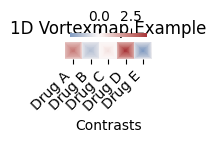

Mean effect sizes:
    Drug A    Drug B    Drug C    Drug D    Drug E
  1.502749 -0.803043  0.102189  2.213707 -1.209742


In [60]:
# Example 1: 1D layout (horizontal vortexmap)
# Generate some example bootstrap data with 5000 values each
np.random.seed(42)
bootstrap_1d = [
    np.random.normal(1.5, 0.5, 5000),    # Positive effect
    np.random.normal(-0.8, 0.3, 5000),   # Negative effect  
    np.random.normal(0.1, 0.2, 5000),    # Small effect
    np.random.normal(2.2, 0.8, 5000),    # Large positive effect
    np.random.normal(-1.2, 0.6, 5000)    # Large negative effect
]

labels_1d = ['Drug A', 'Drug B', 'Drug C', 'Drug D', 'Drug E']

fig, ax, means = fast_vortexmap(
    bootstrap_1d, 
    labels=labels_1d,
    n=21,
    chop_tail=2.5,
    cmap='vlag'
)

plt.title('1D Vortexmap Example')
plt.show()

print("Mean effect sizes:")
print(means)

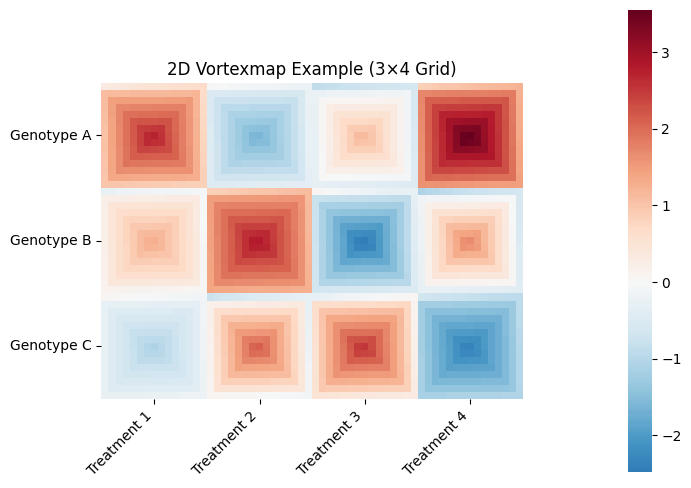

Mean effect sizes:
            Treatment 1  Treatment 2  Treatment 3  Treatment 4
Genotype A     1.508588    -0.800900     0.106829     2.193542
Genotype B     0.499722     1.807964    -1.196659     0.304311
Genotype C    -0.497973     0.694121     1.099444    -1.506061


In [61]:
# Example 2: 2D layout (grid vortexmap)
np.random.seed(123)

# Create 3x4 grid of bootstrap data with 5000 values each
bootstrap_2d = []
effects = [
    [1.5, -0.8, 0.1, 2.2],   # Row 1: varying effects
    [0.5, 1.8, -1.2, 0.3],   # Row 2: different pattern
    [-0.5, 0.7, 1.1, -1.5]   # Row 3: mixed effects
]

for row_effects in effects:
    row_bootstraps = []
    for effect in row_effects:
        # Add some variation in bootstrap distribution width
        width = np.random.uniform(0.2, 0.8)
        bootstrap = np.random.normal(effect, width, 5000)
        row_bootstraps.append(bootstrap)
    bootstrap_2d.append(row_bootstraps)

labels_2d = ['Treatment 1', 'Treatment 2', 'Treatment 3', 'Treatment 4']
row_labels_2d = ['Genotype A', 'Genotype B', 'Genotype C']

fig, ax, means = fast_vortexmap(
    bootstrap_2d,
    labels=labels_2d,
    row_labels=row_labels_2d,
    n=15,  # Smaller spirals for better visualization with more contrasts
    chop_tail=2.5,
    cmap='RdBu_r',
    fig_size=(8, 6)
)

plt.title('2D Vortexmap Example (3×4 Grid)')
plt.show()

print("Mean effect sizes:")
print(means)

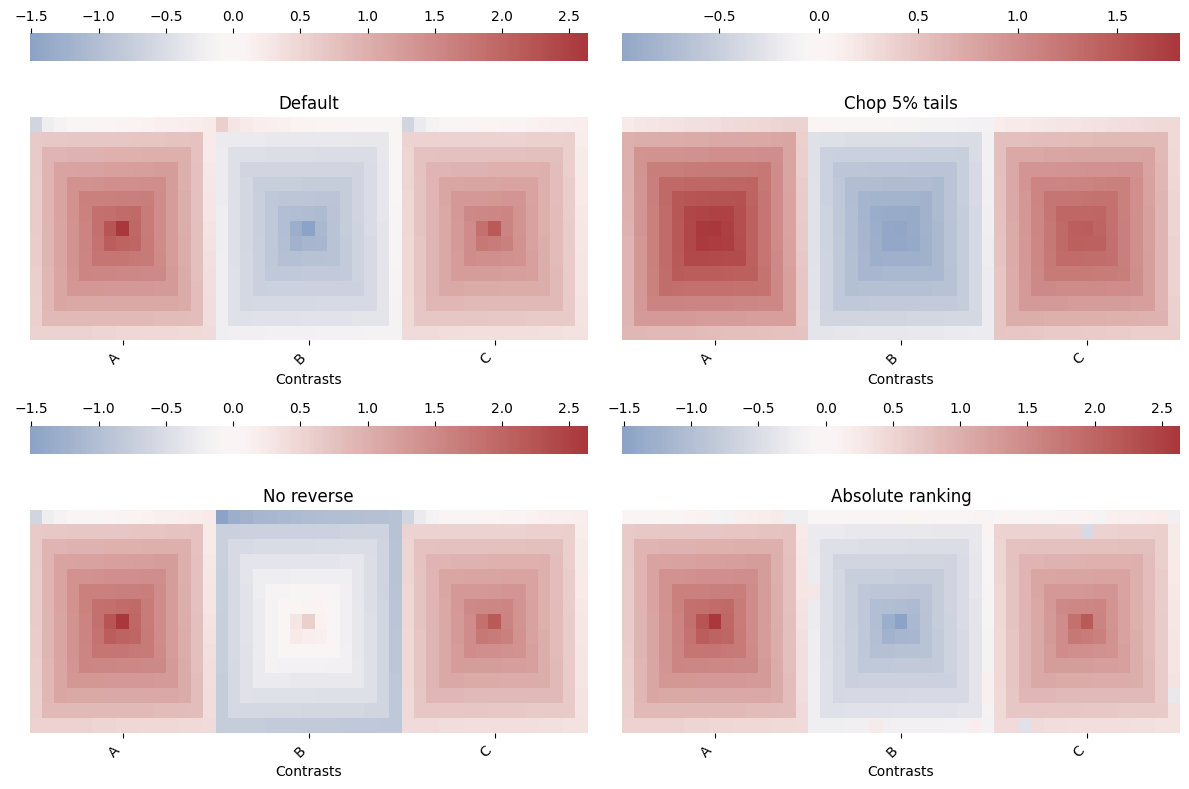

In [62]:
# Example 3: Comparison with different parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

# Use same bootstrap data for comparison (5000 values each)
bootstrap_comparison = [
    np.random.normal(1, 0.5, 5000),
    np.random.normal(-0.5, 0.3, 5000),
    np.random.normal(0.8, 0.4, 5000)
]

labels_comp = ['A', 'B', 'C']

# Different parameter combinations
params = [
    {'chop_tail': 0, 'reverse_neg': True, 'title': 'Default'},
    {'chop_tail': 5, 'reverse_neg': True, 'title': 'Chop 5% tails'},
    {'chop_tail': 0, 'reverse_neg': False, 'title': 'No reverse'},
    {'chop_tail': 0, 'abs_rank': True, 'title': 'Absolute ranking'}
]

for i, param in enumerate(params):
    title = param.pop('title')
    ax, means = fast_vortexmap(
        bootstrap_comparison,
        labels=labels_comp,
        ax=axes[i],
        n=15,
        **param
    )
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

## Comparison with raw data

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import dabest
from dabest.multi import combine, vortexmap
     

def create_delta_dataset(N=20, 
                        seed=9999, 
                        second_quarter_adjustment=3, 
                        third_quarter_adjustment=-0.1,
                        scale2=1, initial_loc = 3):
    """Create a sample dataset for delta-delta analysis."""
    np.random.seed(seed)

    # Create samples
    y = norm.rvs(loc=initial_loc, scale=0.4, size=N*4)
    y[N:2*N] = norm.rvs(loc=initial_loc + second_quarter_adjustment, scale=scale2, size=N) 
    y[2*N:3*N] = norm.rvs(loc=initial_loc + third_quarter_adjustment, scale=0.4, size=N)
    y[3*N:4*N] = norm.rvs(loc=initial_loc, scale=0.4, size=N)

    # Treatment, Rep, Genotype, and ID columns
    treatment = np.repeat(['Placebo', 'Drug'], N*2).tolist()
    genotype = np.repeat(['W', 'M', 'W', 'M'], N).tolist()
    id_col = list(range(0, N*2)) * 2

    # Combine all columns into a DataFrame
    df = pd.DataFrame({
        'ID': id_col,
        'Genotype': genotype,
        'Treatment': treatment,
        'Tumor Size': y
    })

    return df

In [64]:
df_drug1 = create_delta_dataset(seed=9999, second_quarter_adjustment=1, third_quarter_adjustment=-0.5)
df_drug2 = create_delta_dataset(seed=9999, second_quarter_adjustment=0.1, third_quarter_adjustment=-1)
df_drug3 = create_delta_dataset(seed=9999, second_quarter_adjustment=2, third_quarter_adjustment=-0.5)
df_drug4 = create_delta_dataset(seed=9999, second_quarter_adjustment=1, third_quarter_adjustment=-0.1, scale2=7)
df_drug5 = create_delta_dataset(seed=9999, second_quarter_adjustment=0.1, third_quarter_adjustment=-0.3, scale2=7)

dabest_obj1 = dabest.load(data=df_drug1, 
                       x=["Genotype", "Genotype"], 
                       y="Tumor Size", 
                       delta2=True, 
                       experiment="Treatment")

dabest_obj2 = dabest.load(data=df_drug2, 
                       x=["Genotype", "Genotype"], 
                       y="Tumor Size", 
                       delta2=True, 
                       experiment="Treatment")

dabest_obj3 = dabest.load(data=df_drug3, 
                       x=["Genotype", "Genotype"], 
                       y="Tumor Size", 
                       delta2=True, 
                       experiment="Treatment")

dabest_obj4 = dabest.load(data=df_drug4, 
                       x=["Genotype", "Genotype"], 
                       y="Tumor Size", 
                       delta2=True, 
                       experiment="Treatment")

dabest_obj5 = dabest.load(data=df_drug5, 
                       x=["Genotype", "Genotype"], 
                       y="Tumor Size", 
                       delta2=True, 
                       experiment="Treatment")

dabest_objs = [dabest_obj1, dabest_obj2, dabest_obj3, dabest_obj4, dabest_obj5]
dabest_objs2 = [[dabest_obj1, dabest_obj2, dabest_obj3, dabest_obj4, dabest_obj5], [dabest_obj1, dabest_obj2, dabest_obj3, dabest_obj4, dabest_obj5]]
     

In [65]:
def bootstrap_extraction(dfsp_db2): 
    """Extract bootstrap values from a DABEST delta2 object.
    
    Parameters
    ----------
    dfsp_db2 : dabest object
        DABEST object with delta2=True
    
    Returns
    -------
    numpy.ndarray
        Array of 5000 bootstrap values
    """
    bootstrap_values = dfsp_db2.mean_diff.delta_delta.bootstraps_delta_delta
    return np.array(bootstrap_values)

In [66]:
# Test the bootstrap extraction function
bootstrap_test = bootstrap_extraction(dabest_obj2)
print(f"Bootstrap extraction successful! Shape: {bootstrap_test.shape}")
print(f"First 10 values: {bootstrap_test[:10]}")
print(f"Mean: {np.mean(bootstrap_test):.3f}")
print(f"Std: {np.std(bootstrap_test):.3f}")

Bootstrap extraction successful! Shape: (5000,)
First 10 values: [1.1962538  1.32962638 0.74794404 1.63210533 1.10706916 0.6466728
 0.09981389 1.19810174 0.52148553 0.66278532]
Mean: 1.100
Std: 0.315


In [67]:
# Now let's do a proper comparison between original DABEST vortexmap and our fast_vortexmap
# using the SAME bootstrap data extracted from the SAME DABEST objects

print("=== COMPARISON: Original DABEST vs Fast Vortexmap ===")
print("Using identical bootstrap data extracted from the same DABEST objects...\\n")

# Step 1: Extract bootstrap values from all 5 DABEST objects
bootstrap_data_extracted = []
for i, dabest_obj in enumerate([dabest_obj1, dabest_obj2, dabest_obj3, dabest_obj4, dabest_obj5]):
    bootstrap_values = bootstrap_extraction(dabest_obj)
    bootstrap_data_extracted.append(bootstrap_values)
    print(f"Drug {i+1}: Extracted {len(bootstrap_values)} bootstrap values, mean = {np.mean(bootstrap_values):.3f}")

print(f"\\nTotal bootstrap arrays extracted: {len(bootstrap_data_extracted)}")
print(f"Bootstrap array size: {len(bootstrap_data_extracted[0])} values each\\n")

=== COMPARISON: Original DABEST vs Fast Vortexmap ===
Using identical bootstrap data extracted from the same DABEST objects...\n
Drug 1: Extracted 5000 bootstrap values, mean = -0.300
Drug 2: Extracted 5000 bootstrap values, mean = 1.100
Drug 3: Extracted 5000 bootstrap values, mean = -1.300
Drug 4: Extracted 5000 bootstrap values, mean = 0.712
Drug 5: Extracted 5000 bootstrap values, mean = 1.812
\nTotal bootstrap arrays extracted: 5
Bootstrap array size: 5000 values each\n


Creating original DABEST vortexmap...


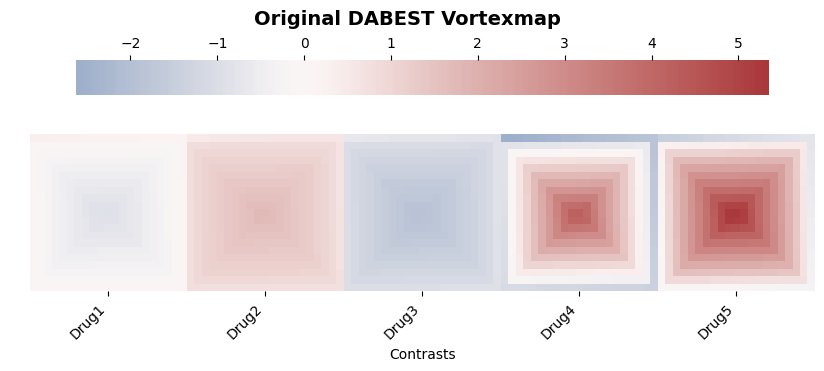

Original DABEST mean deltas:
     Drug1     Drug2     Drug3     Drug4     Drug5
 -0.300041  1.099429 -1.300041  0.702739  1.802739



In [68]:
# Step 2: Create original DABEST MultiContrast vortexmap
print("Creating original DABEST vortexmap...")

multi_1d_original = combine([dabest_obj1, dabest_obj2, dabest_obj3, dabest_obj4, dabest_obj5], 
                          labels=["Drug1", "Drug2", "Drug3", "Drug4", "Drug5"])

fig_original, ax_original, mean_delta_original = multi_1d_original.vortexmap(
    n=21,
    chop_tail=2.5,
    cmap="vlag",
    fig_size=(12, 3)
)
plt.suptitle('Original DABEST Vortexmap', y=1.05, fontsize=14, fontweight='bold')
plt.show()

print("Original DABEST mean deltas:")
print(mean_delta_original)
print()

Creating fast_vortexmap using extracted bootstrap data...


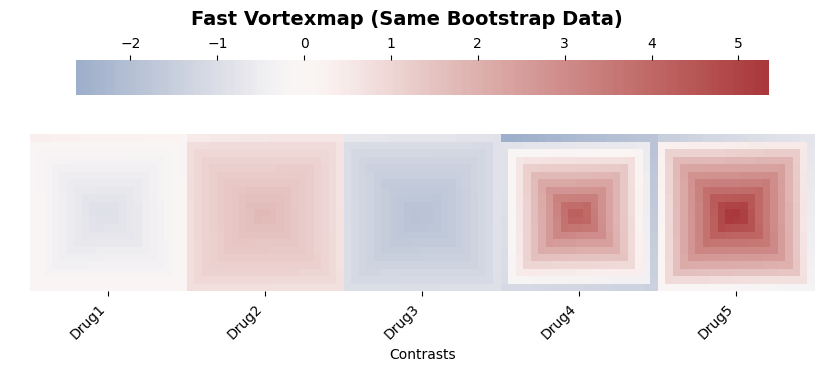

Fast vortexmap mean deltas:
     Drug1     Drug2     Drug3     Drug4     Drug5
 -0.300041  1.099429 -1.300041  0.702739  1.802739



In [69]:
# Step 3: Create fast_vortexmap using SAME bootstrap data
print("Creating fast_vortexmap using extracted bootstrap data...")
fig_fast, ax_fast, mean_delta_fast = fast_vortexmap(
    bootstrap_data_extracted,
    labels=["Drug1", "Drug2", "Drug3", "Drug4", "Drug5"],
    n=21,
    chop_tail=2.5,
    cmap="vlag",
    fig_size=(12, 3)
)
plt.suptitle('Fast Vortexmap (Same Bootstrap Data)', y=1.05, fontsize=14, fontweight='bold')
plt.show()

print("Fast vortexmap mean deltas:")
print(mean_delta_fast)
print()

In [70]:
# Step 4: Compare the results numerically
print("=== NUMERICAL COMPARISON ===")
mean_diff = np.abs(mean_delta_original.values - mean_delta_fast.values)
max_diff = np.max(mean_diff)
print(f"Maximum absolute difference in mean deltas: {max_diff:.10f}")
print(f"Are results identical? {max_diff < 1e-10}")

if max_diff < 1e-10:
    print("✅ SUCCESS: Both methods produce identical results!")
else:
    print("❌ WARNING: Results differ - check implementation")
    print("Differences:")
    print(mean_diff)
    
print("\\n=== SIDE-BY-SIDE COMPARISON ===")
comparison_df = pd.DataFrame({
    'Original_DABEST': mean_delta_original.values.flatten(),
    'Fast_Vortexmap': mean_delta_fast.values.flatten(),
    'Absolute_Difference': mean_diff.flatten()
}, index=["Drug1", "Drug2", "Drug3", "Drug4", "Drug5"])

print(comparison_df)


=== NUMERICAL COMPARISON ===
Maximum absolute difference in mean deltas: 0.0000000000
Are results identical? True
✅ SUCCESS: Both methods produce identical results!
\n=== SIDE-BY-SIDE COMPARISON ===
       Original_DABEST  Fast_Vortexmap  Absolute_Difference
Drug1        -0.300041       -0.300041                  0.0
Drug2         1.099429        1.099429                  0.0
Drug3        -1.300041       -1.300041                  0.0
Drug4         0.702739        0.702739                  0.0
Drug5         1.802739        1.802739                  0.0


## Loading with csv files

In [3]:
def load_driver_responder_csv(filepath):
    """
    Load CSV file with driver-responder format.
    
    Parameters
    ----------
    filepath : str
        Path to CSV file with format "{driver} x {responder} all stats.csv"
    
    Returns
    -------
    tuple
        (bootstrap_data, metric_labels, driver_name, responder_name)
        
    Notes
    -----
    Each CSV contains data for ONE driver only. The MBON column just repeats 
    the driver name 5000 times (once per bootstrap row).
        
    Examples
    --------
    bootstrap_data, metrics, driver, responder = load_driver_responder_csv("MB011B x ACR all stats.csv")
    """
    import os
    
    # Extract driver and responder from filename
    filename = os.path.basename(filepath)
    base_name = filename.replace(" all stats.csv", "").replace("all stats.csv", "")
    
    if " x " in base_name:
        driver_name, responder_name = base_name.split(" x ")
        driver_name = driver_name.strip()
        responder_name = responder_name.strip()
    else:
        raise ValueError(f"Filename '{filename}' doesn't match expected format 'driver x responder all stats.csv'")
    
    # Load the CSV
    df = pd.read_csv(filepath)
    
    # Verify MBON column contains the expected driver name (should be all the same)
    if 'MBON' in df.columns:
        unique_mbons = df['MBON'].unique()
        if len(unique_mbons) == 1:
            csv_driver_name = unique_mbons[0]
        else:
            print(f"WARNING: MBON column contains multiple values: {unique_mbons}")
            csv_driver_name = unique_mbons[0]  # Use first one
    else:
        print("No MBON column found, using driver name from filename")
        csv_driver_name = driver_name
    
    # Find all bootstrap columns (ending with '_bootstrap')
    bootstrap_cols = [col for col in df.columns if col.endswith('_bootstrap')]
    
    if not bootstrap_cols:
        raise ValueError("No columns ending with '_bootstrap' found")
    
    # Extract metric names (remove '_bootstrap' suffix)
    metric_labels = [col.replace('_bootstrap', '') for col in bootstrap_cols]
    
    # print(f"Found {len(bootstrap_cols)} bootstrap columns for metrics: {metric_labels}")
    # print(f"Each metric has {len(df)} bootstrap values")
    
    # Extract bootstrap data - one array per metric
    bootstrap_data = []
    for bootstrap_col in bootstrap_cols:
        # Get all bootstrap values for this metric (should be 5000 values)
        bootstrap_values = df[bootstrap_col].values
        
        # Convert to numpy array
        bootstrap_data.append(np.array(bootstrap_values))
        
        # print(f"  {bootstrap_col}: {len(bootstrap_values)} values, mean = {np.mean(bootstrap_values):.3f}")
    
    return bootstrap_data, metric_labels, csv_driver_name, responder_name

def load_multiple_driver_responder_csvs(file_patterns):
    """
    Load multiple CSV files and combine them for 2D vortexmap.
    
    Each CSV file contains one driver's data across multiple metrics.
    
    Parameters
    ----------
    file_patterns : list of str
        List of CSV file paths
        
    Returns
    -------
    tuple
        (combined_bootstrap_data, metric_labels, driver_names, experiment_labels)
    """
    all_bootstrap_data = []
    all_driver_names = []
    all_experiment_labels = []
    metric_labels = None
    
    for filepath in file_patterns:
        bootstrap_data, metrics, driver_name, responder_name = load_driver_responder_csv(filepath)
        
        # Store data - each file contributes one row (one driver) to the 2D structure
        all_bootstrap_data.append(bootstrap_data)  # bootstrap_data is list of arrays (one per metric)
        all_driver_names.append(driver_name)  # Just one driver name per file
        all_experiment_labels.append(f"{driver_name} x {responder_name}")
        
        # Check that metrics are consistent across files
        if metric_labels is None:
            metric_labels = metrics
        elif metrics != metric_labels:
            raise ValueError(f"Metric labels don't match across files: {metrics} vs {metric_labels}")
    
    # print(f"\\nCombined data structure:")
    # print(f"Total drivers: {len(all_driver_names)} ({all_driver_names})")
    # print(f"Total metrics: {len(metric_labels)} ({metric_labels})")
    # print(f"Structure: {len(all_driver_names)} drivers × {len(metric_labels)} metrics")
    
    return all_bootstrap_data, metric_labels, all_driver_names, all_experiment_labels

Creating 1D vortexmap for MB011B x ACR allstats.csv...


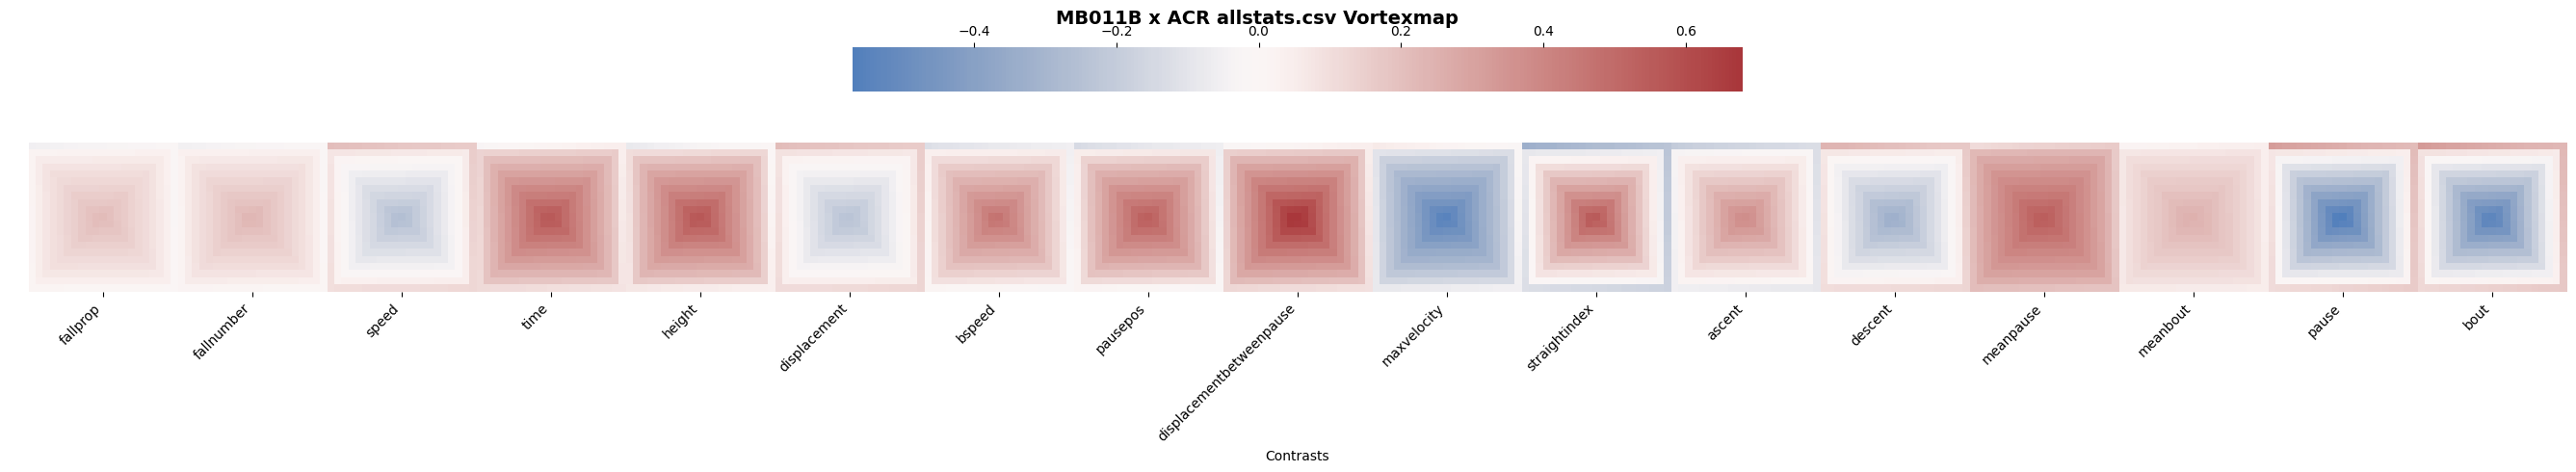

In [4]:
bootstrap_data_1, metrics_1, driver_1, responder_1 = load_driver_responder_csv("MB011B x ACR allstats.csv")
bootstrap_data_2, metrics_2, driver_2, responder_2 = load_driver_responder_csv("MB018B x ACR allstats.csv")

# Create vortexmap for MB011B x ACR (1D horizontal layout - one driver, multiple metrics)
print(f"Creating 1D vortexmap for {driver_1} x {responder_1}...")
fig1, ax1, means1 = fast_vortexmap(
    bootstrap_data_1,  # List of bootstrap arrays, one per metric
    labels=metrics_1,   # Metric names as column labels
    n=21,              # Standard spiral size
    chop_tail=2.5,
    cmap='vlag',
    fig_size=(len(metrics_1) * 2, 4)  # Width based on number of metrics
)
plt.suptitle(f'{driver_1} x {responder_1} Vortexmap', fontsize=14, fontweight='bold')
plt.show()

    

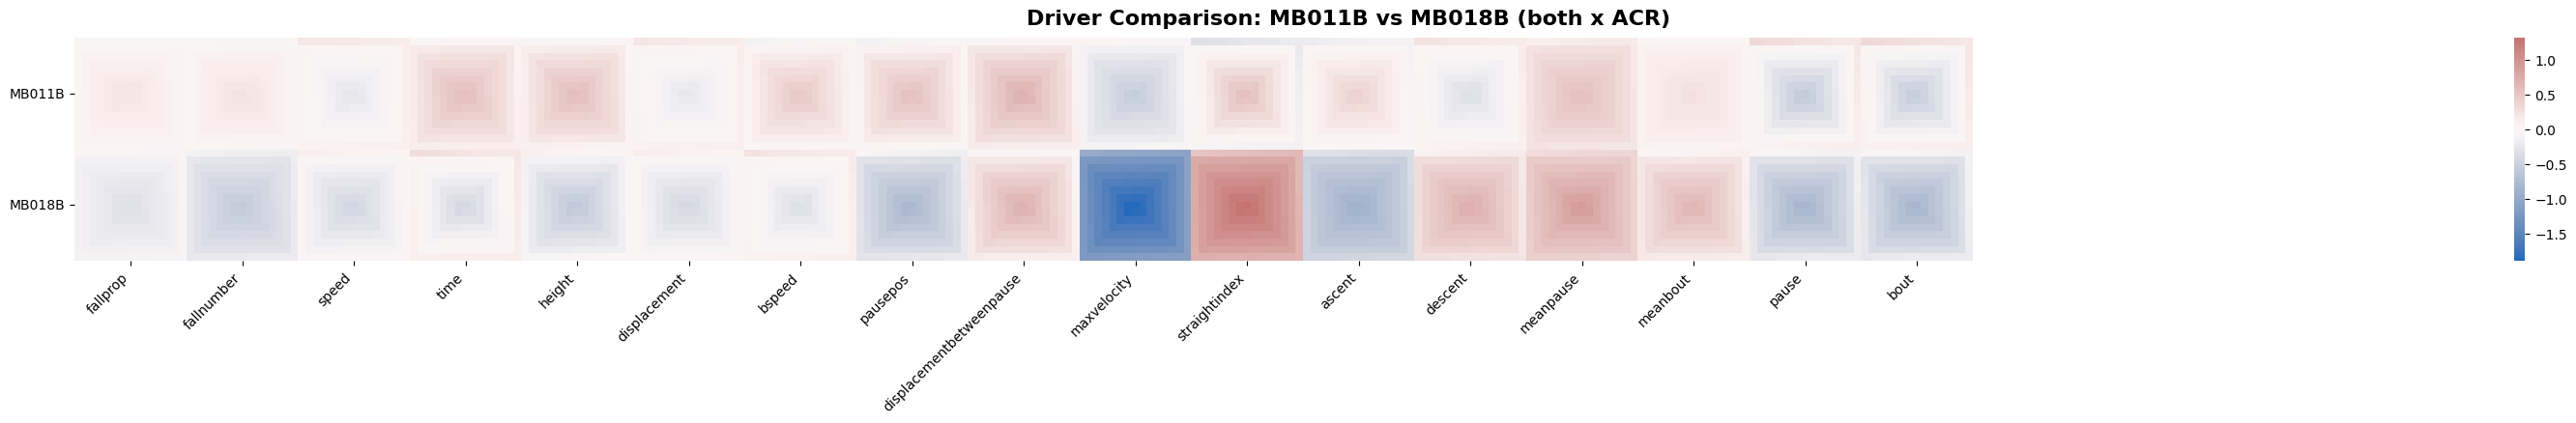

In [5]:
# Create a combined 2D vortexmap comparing both experiments


# Load multiple files and combine them
combined_data, combined_metrics, combined_drivers, experiment_labels = load_multiple_driver_responder_csvs([
    "MB011B x ACR allstats.csv",
    "MB018B x ACR allstats.csv"
])

# combined_data is now: [[metric1_bootstrap_array, metric2_array, ...], [metric1_array, metric2_array, ...]]
# This is already in the right format for fast_vortexmap 2D mode

fig_combined, ax_combined, means_combined = fast_vortexmap(
    combined_data,           # 2D structure: each row is one driver's metrics
    labels=combined_metrics, # Metric names as column labels
    row_labels=combined_drivers, # Driver names as row labels
    n=15,                    # Smaller spirals for comparison view
    chop_tail=2.5,
    cmap='vlag',
    fig_size=(len(combined_metrics) * 2.5, len(combined_drivers) * 1.5)
)

plt.suptitle('Driver Comparison: MB011B vs MB018B (both x ACR)', 
                fontsize=16, fontweight='bold', y=0.98)
plt.show()



\n=== CREATING COMBINED 2D VORTEXMAP ===
Combining both experiments into a single comparison vortexmap...
\nOriginal combined_data structure:
Number of drivers: 2 (should be 2)
Number of metrics per driver: 17 (should be 17)
Bootstrap values per metric: 5000 (should be 5000)
\nCreating 2D comparison vortexmap...
Structure: 2 drivers (rows) × 17 metrics (columns)


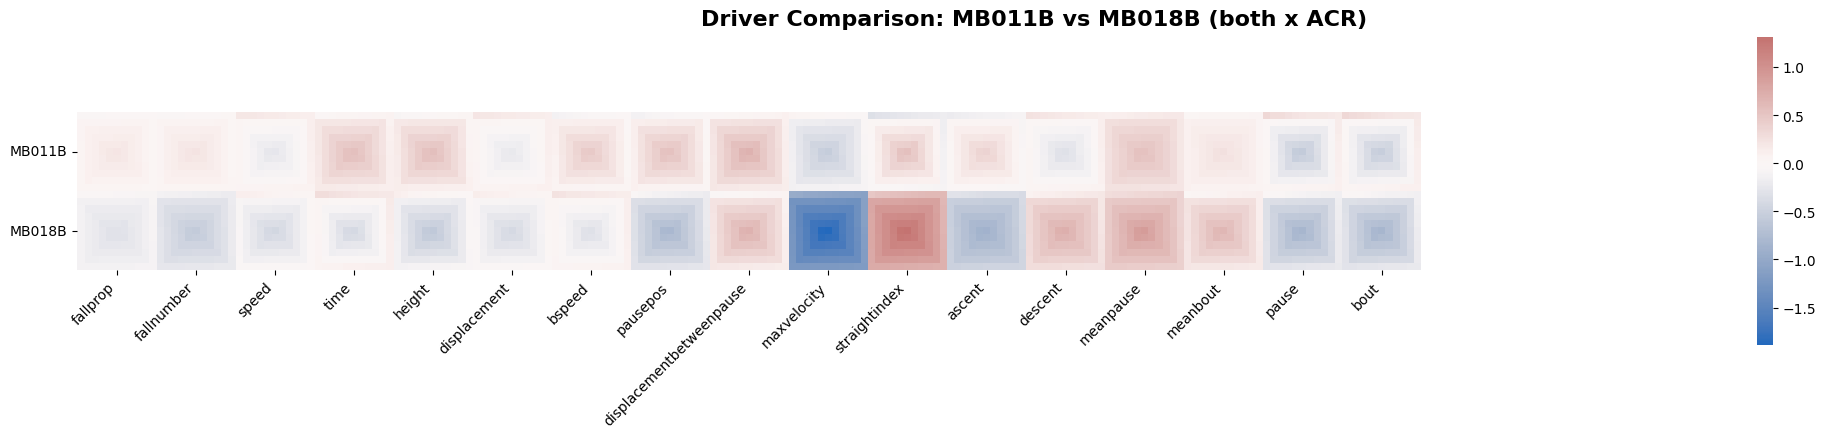

\nCombined mean effect sizes:
        fallprop  fallnumber     speed      time    height  displacement  \
MB011B  0.080525    0.089713 -0.026501  0.262148  0.245100     -0.015212   
MB018B -0.173383   -0.335982 -0.149496 -0.051073 -0.238428     -0.134720   

          bspeed  pausepos  displacementbetweenpause  maxvelocity  \
MB011B  0.164468  0.203952                  0.306725    -0.239220   
MB018B -0.040271 -0.426331                  0.307497    -1.401395   

        straightindex    ascent   descent  meanpause  meanbout     pause  \
MB011B       0.105075  0.091160 -0.050018   0.319526  0.126354 -0.120561   
MB018B       0.893338 -0.588923  0.392400   0.546408  0.313670 -0.427155   

            bout  
MB011B -0.100707  
MB018B -0.420840  
\n=== COMPARISON INSIGHTS ===
Effect size differences (MB011B - MB018B) for each metric:
  fallprop                 : MB011B= 0.081, MB018B=-0.173, Diff= 0.254
  fallnumber               : MB011B= 0.090, MB018B=-0.336, Diff= 0.426
  speed         

In [6]:
# Create a combined 2D vortexmap comparing both experiments
print("\\n=== CREATING COMBINED 2D VORTEXMAP ===")
print("Combining both experiments into a single comparison vortexmap...")

# Load multiple files and combine them  
combined_data, combined_metrics, combined_drivers, experiment_labels = load_multiple_driver_responder_csvs([
    "MB011B x ACR allstats.csv",
    "MB018B x ACR allstats.csv"
])

print(f"\\nOriginal combined_data structure:")
print(f"Number of drivers: {len(combined_data)} (should be 2)")
print(f"Number of metrics per driver: {len(combined_data[0])} (should be 17)")
print(f"Bootstrap values per metric: {len(combined_data[0][0])} (should be 5000)")

print(f"\\nCreating 2D comparison vortexmap...")
print(f"Structure: {len(combined_drivers)} drivers (rows) × {len(combined_metrics)} metrics (columns)")

# The combined_data is already in the correct format: 
# [[MB011B_metric1, MB011B_metric2, ...], [MB018B_metric1, MB018B_metric2, ...]]
# This is perfect for 2D vortexmap: 2 rows (drivers) × 17 columns (metrics)

fig_combined, ax_combined, means_combined = fast_vortexmap(
    combined_data,           # 2D structure: each row is one driver's metrics
    labels=combined_metrics, # 17 metric names as column labels  
    row_labels=combined_drivers, # 2 driver names as row labels
    n=11,                    # Smaller spirals for comparison view
    chop_tail=2.5,
    cmap='vlag',
    fig_size=(len(combined_metrics) * 1.5, len(combined_drivers) * 2)
)

plt.suptitle('Driver Comparison: MB011B vs MB018B (both x ACR)', 
             fontsize=16, fontweight='bold', y=0.95)
plt.show()

print("\\nCombined mean effect sizes:")
print(means_combined)

print("\\n=== COMPARISON INSIGHTS ===")
# Calculate differences between the two drivers for each metric
print("Effect size differences (MB011B - MB018B) for each metric:")
differences = []
for i, metric in enumerate(combined_metrics):
    mb011b_effect = means_combined.iloc[0, i]  # Row 0 = MB011B
    mb018b_effect = means_combined.iloc[1, i]  # Row 1 = MB018B  
    difference = mb011b_effect - mb018b_effect
    differences.append(abs(difference))
    print(f"  {metric:25s}: MB011B={mb011b_effect:6.3f}, MB018B={mb018b_effect:6.3f}, Diff={difference:6.3f}")

# Find metrics with biggest differences
sorted_diffs = sorted(zip(combined_metrics, differences), key=lambda x: x[1], reverse=True)
print(f"\\nTop 5 metrics with biggest differences between drivers:")
for i, (metric, diff) in enumerate(sorted_diffs[:5]):
    print(f"  {i+1}. {metric}: {diff:.3f}")

print(f"\\nBottom 5 metrics with smallest differences between drivers:")
for i, (metric, diff) in enumerate(sorted_diffs[-5:]):
    print(f"  {i+1}. {metric}: {diff:.3f}")